# Cluster Analysis – B2B Contact Segmentation

This notebook applies clustering to the preprocessed **contact** (Ansprechpartner) dataset:
1. **K-Means** (with Elbow + Silhouette for optimal k)
2. **Hierarchical Clustering** (Ward linkage)
3. **DBSCAN** (density-based)
4. **HDBSCAN** (density-based, automatic cluster detection)

Finally, all methods are compared side by side and exported to Excel.

In [476]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import hdbscan

In [477]:
df_contacts_scaled = pd.read_csv('data/df_contacts_final.csv', index_col='contact_id')
feature_matrix_contacts = df_contacts_scaled.values

print(f'Dataset: {df_contacts_scaled.shape[0]} contacts, {df_contacts_scaled.shape[1]} features')
df_contacts_scaled.head()

Dataset: 1126 contacts, 27 features


,Recency,Frequency,Regale,Lager Zubehör,Sonstige Produkte,Monetary Value,Werkstätte_gesamt,Garderoben_gesamt,industry_group_ZG 1+2,industry_group_ZG 3+4,...,company_size_Groß,company_size_Klein,company_size_Mittel,department_Einkauf & Beschaffung,department_Führung & Leitung,department_Technik & Produktion,department_Verwaltung & Vertrieb,type_detail_Gewerbl. Nutzer,type_detail_Multiplikator,type_detail_Wiederverkäufer
contact_id,,,,,,,,,,,,,,,,,,,,,
0,-0.135304,-0.039859,-0.317468,-0.132678,-0.319277,-0.456871,-0.168865,-0.359903,1.931604,-0.243447,...,-0.803865,-0.444828,1.122962,1.611659,-0.587606,-0.602658,-0.498334,0.292958,-0.168257,-0.233039
1,1.414632,-0.360435,-0.317468,-0.132678,-0.319277,-0.476266,-0.198101,-0.359903,1.931604,-0.243447,...,-0.803865,-0.444828,1.122962,-0.620479,1.701821,-0.602658,-0.498334,0.292958,-0.168257,-0.233039
2,1.150632,-0.360435,-0.307340,-0.132678,-0.319277,-0.474422,-0.200437,-0.359903,1.931604,-0.243447,...,-0.803865,-0.444828,1.122962,-0.620479,-0.587606,1.659317,-0.498334,0.292958,-0.168257,-0.233039
3,-0.758401,-0.039859,-0.317468,-0.132678,-0.319277,-0.472256,-0.200437,-0.349193,1.931604,-0.243447,...,-0.803865,-0.444828,1.122962,-0.620479,-0.587606,1.659317,-0.498334,0.292958,-0.168257,-0.233039
4,1.475664,-0.360435,-0.317468,-0.132678,-0.319277,-0.439821,-0.200437,-0.286719,1.931604,-0.243447,...,-0.803865,-0.444828,1.122962,1.611659,-0.587606,-0.602658,-0.498334,0.292958,-0.168257,-0.233039


## 1. K-Means Clustering

### 1.1 Determine optimal number of clusters k

- **Elbow Method**: Plot inertia (within-cluster sum of squares) for k = 2 .. 9. Look for the "elbow" where adding more clusters stops reducing inertia significantly.
- **Silhouette Score**: Higher is better (range -1 to 1). Measures how similar each point is to its own cluster vs. neighbouring clusters.

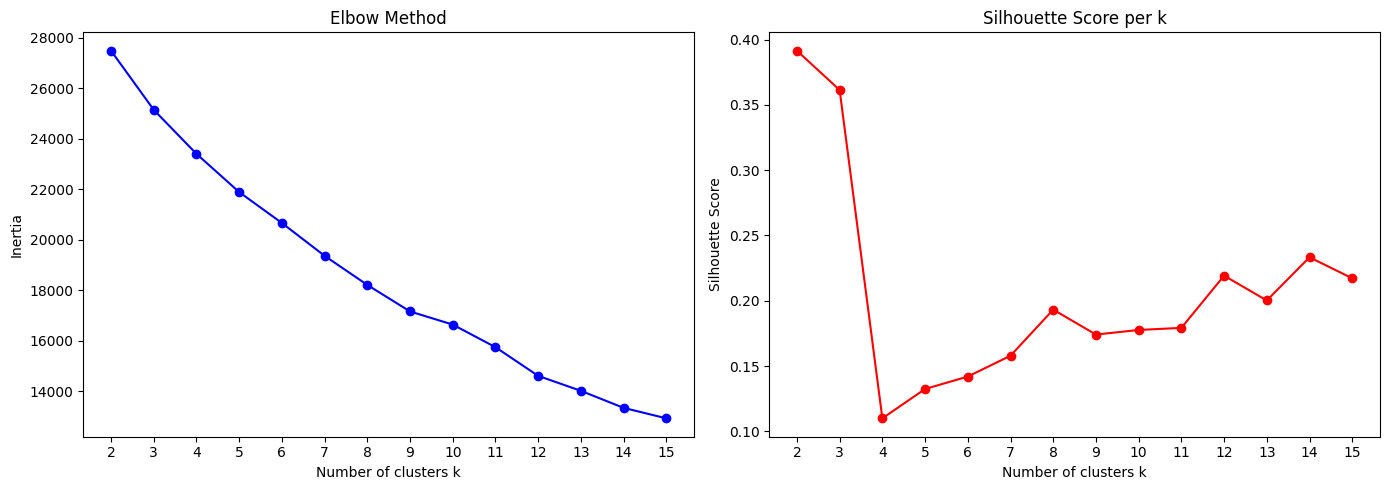

k= 2  |  Inertia:    27488.8  |  Silhouette: 0.3914
k= 3  |  Inertia:    25147.5  |  Silhouette: 0.3614
k= 4  |  Inertia:    23405.6  |  Silhouette: 0.1100
k= 5  |  Inertia:    21891.8  |  Silhouette: 0.1324
k= 6  |  Inertia:    20667.8  |  Silhouette: 0.1419
k= 7  |  Inertia:    19367.8  |  Silhouette: 0.1579
k= 8  |  Inertia:    18215.7  |  Silhouette: 0.1932
k= 9  |  Inertia:    17165.4  |  Silhouette: 0.1741
k=10  |  Inertia:    16646.4  |  Silhouette: 0.1776
k=11  |  Inertia:    15750.8  |  Silhouette: 0.1792
k=12  |  Inertia:    14615.7  |  Silhouette: 0.2192
k=13  |  Inertia:    14023.7  |  Silhouette: 0.2002
k=14  |  Inertia:    13349.3  |  Silhouette: 0.2333
k=15  |  Inertia:    12935.0  |  Silhouette: 0.2172


In [478]:
k_range = range(2, 16)
kmeans_inertia_per_k = []
kmeans_silhouette_per_k = []

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(feature_matrix_contacts)
    kmeans_inertia_per_k.append(kmeans_model.inertia_)
    kmeans_silhouette_per_k.append(silhouette_score(feature_matrix_contacts, labels))

# Plot both metrics side by side
fig, (ax_elbow, ax_silhouette) = plt.subplots(1, 2, figsize=(14, 5))

ax_elbow.plot(k_range, kmeans_inertia_per_k, 'bo-')
ax_elbow.set_xlabel('Number of clusters k')
ax_elbow.set_ylabel('Inertia')
ax_elbow.set_title('Elbow Method')
ax_elbow.set_xticks(list(k_range))

ax_silhouette.plot(k_range, kmeans_silhouette_per_k, 'ro-')
ax_silhouette.set_xlabel('Number of clusters k')
ax_silhouette.set_ylabel('Silhouette Score')
ax_silhouette.set_title('Silhouette Score per k')
ax_silhouette.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Print scores for reference
for k, inertia, sil in zip(k_range, kmeans_inertia_per_k, kmeans_silhouette_per_k):
    print(f'k={k:2d}  |  Inertia: {inertia:10.1f}  |  Silhouette: {sil:.4f}')

### 1.2 Fit K-Means with chosen k

Set `optimal_k_kmeans` below based on the Elbow and Silhouette plots above.

In [479]:
# --- Set the optimal k here based on the plots above ---
optimal_k_kmeans = 12

kmeans_model = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init='auto')
kmeans_cluster_labels = kmeans_model.fit_predict(feature_matrix_contacts)

# Evaluation
kmeans_silhouette = silhouette_score(feature_matrix_contacts, kmeans_cluster_labels)
kmeans_davies_bouldin = davies_bouldin_score(feature_matrix_contacts, kmeans_cluster_labels)

print(f'K-Means (k={optimal_k_kmeans})')
print(f'  Silhouette Score:     {kmeans_silhouette:.4f}')
print(f'  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}')
print(f'\nCluster sizes:')
print(pd.Series(kmeans_cluster_labels).value_counts().sort_index().to_string())

K-Means (k=12)
  Silhouette Score:     0.2096
  Davies-Bouldin Index: 1.4190

Cluster sizes:
0     163
1      64
2      60
3     187
4      11
5     170
6     187
7      31
8      41
9      53
10      2
11    157


## 2. Hierarchical Clustering

### 2.1 Dendrogram (Ward Linkage)

Ward linkage minimises within-cluster variance and is recommended for standardised data.
Two views: overview (last 30 merges) and detail (first 5 levels).

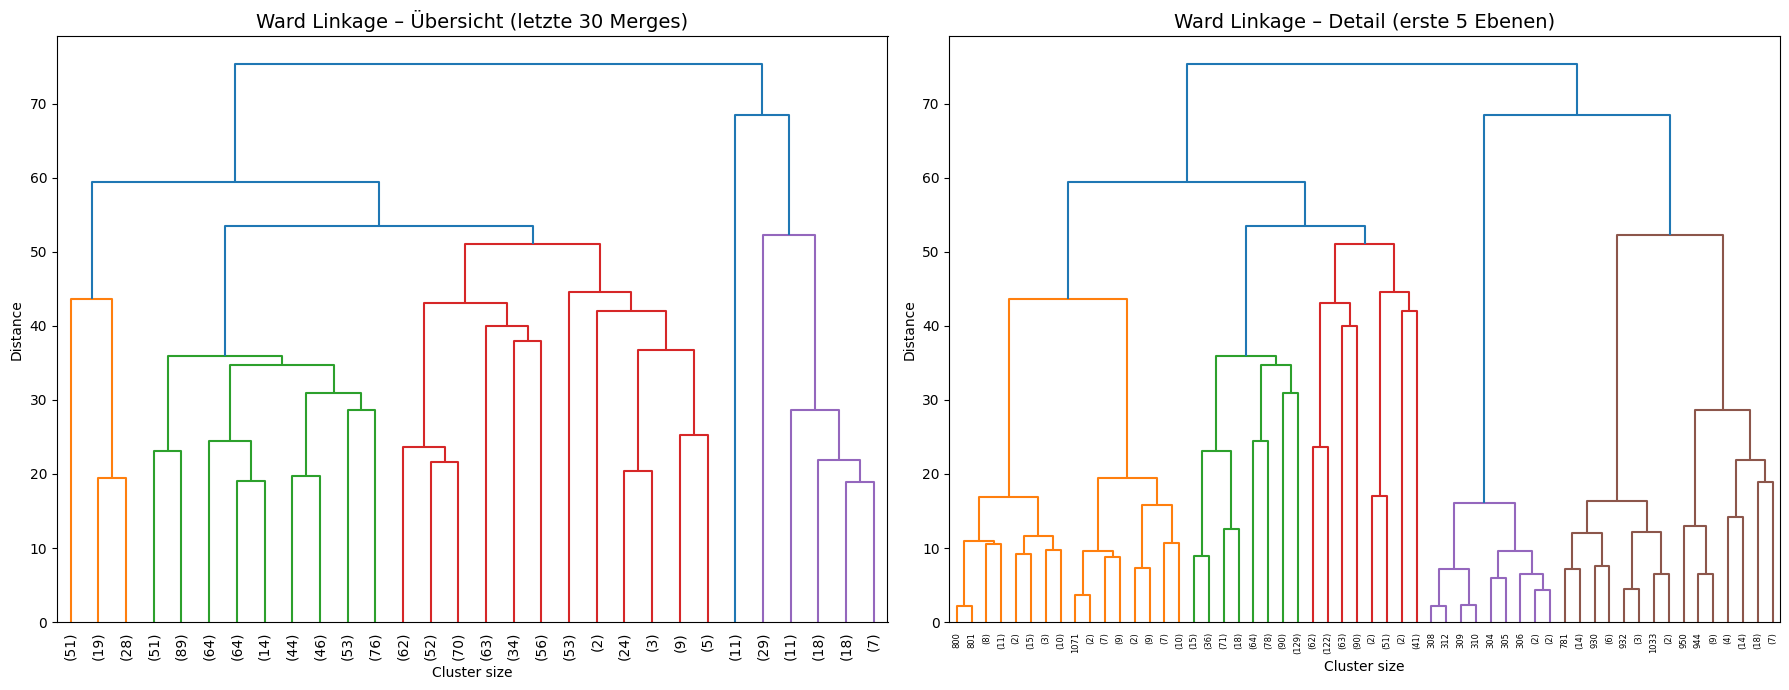

In [480]:
# Compute linkage matrix
ward_linkage = linkage(feature_matrix_contacts, method='ward')

# Plot two dendrogram views
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Overview: last 30 merges
dendrogram(
    ward_linkage,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    ax=axes[0]
)
axes[0].set_title('Ward Linkage – Übersicht (letzte 30 Merges)', fontsize=14)
axes[0].set_xlabel('Cluster size')
axes[0].set_ylabel('Distance')

# Detail: first 5 levels
dendrogram(
    ward_linkage,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    ax=axes[1]
)
axes[1].set_title('Ward Linkage – Detail (erste 5 Ebenen)', fontsize=14)
axes[1].set_xlabel('Cluster size')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

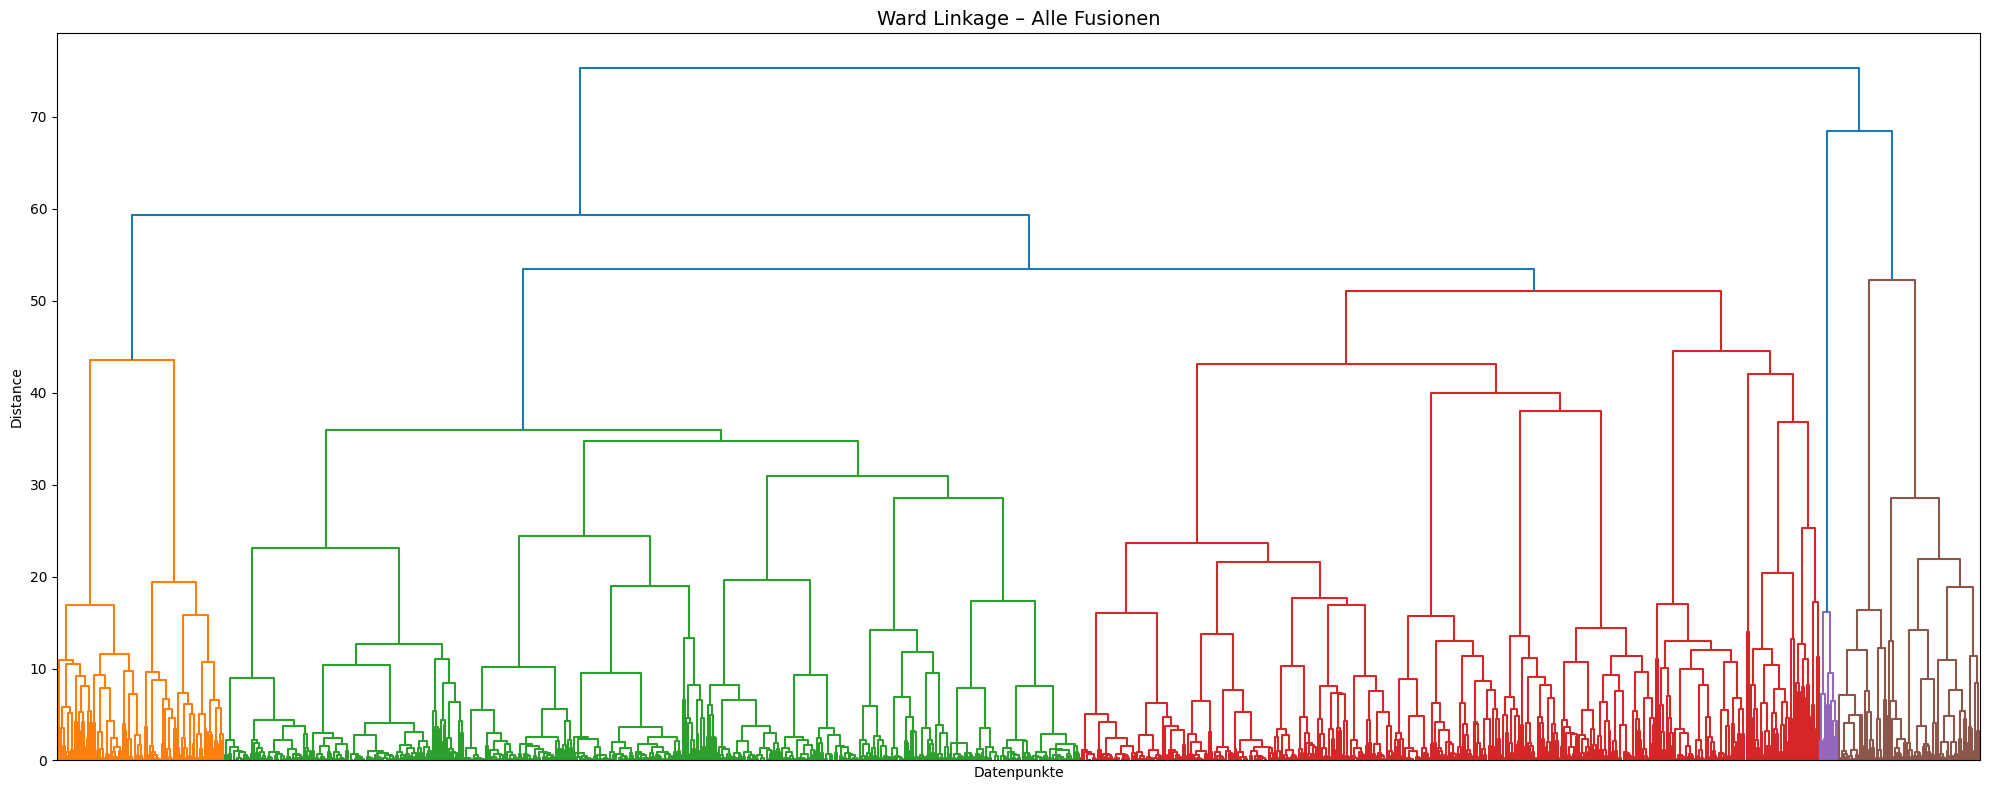

In [481]:
# Full dendrogram (all fusions)
plt.figure(figsize=(20, 8))
dendrogram(
    ward_linkage,
    no_labels=True,
    leaf_rotation=90
)
plt.title('Ward Linkage – Alle Fusionen', fontsize=14)
plt.xlabel('Datenpunkte')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [482]:
k_range = range(2, 16)

silhouette_scores_ward = []
davies_bouldin_scores_ward = []

for k in k_range:
    labels = fcluster(ward_linkage, t=k, criterion='maxclust')
    silhouette_scores_ward.append(silhouette_score(feature_matrix_contacts, labels))
    davies_bouldin_scores_ward.append(davies_bouldin_score(feature_matrix_contacts, labels))

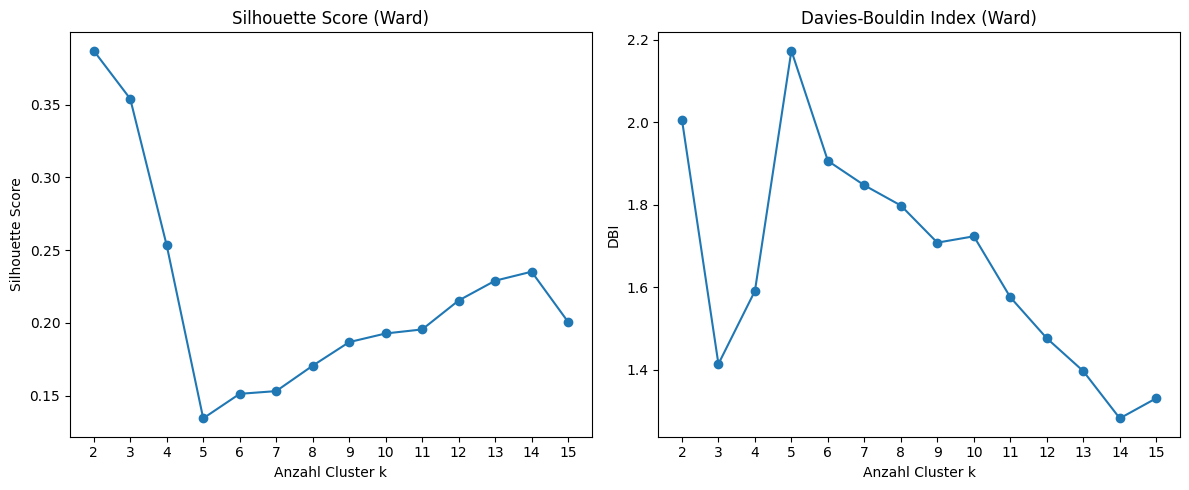

In [483]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores_ward, marker='o')
plt.title('Silhouette Score (Ward)')
plt.xlabel('Anzahl Cluster k')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)

plt.subplot(1, 2, 2)
plt.plot(k_range, davies_bouldin_scores_ward, marker='o')
plt.title('Davies-Bouldin Index (Ward)')
plt.xlabel('Anzahl Cluster k')
plt.ylabel('DBI')
plt.xticks(k_range)

plt.tight_layout()
plt.show()

### 2.2 Cut dendrograms and evaluate

Set `optimal_k_hierarchical` below based on the dendrograms above.

In [484]:
# --- Set the optimal k here based on the dendrograms above ---
optimal_k_hierarchical = 14

hierarchical_cluster_labels = fcluster(ward_linkage, t=optimal_k_hierarchical, criterion='maxclust')

hierarchical_sil = silhouette_score(feature_matrix_contacts, hierarchical_cluster_labels)
hierarchical_dbi = davies_bouldin_score(feature_matrix_contacts, hierarchical_cluster_labels)
cluster_sizes = pd.Series(hierarchical_cluster_labels).value_counts().sort_index().to_dict()

print(f'{"Ward":10s}  |  Silhouette: {hierarchical_sil:.4f}  |  Davies-Bouldin: {hierarchical_dbi:.4f}  |  Sizes: {cluster_sizes}')

Ward        |  Silhouette: 0.2352  |  Davies-Bouldin: 1.2818  |  Sizes: {1: 51, 2: 47, 3: 501, 4: 184, 5: 63, 6: 34, 7: 56, 8: 53, 9: 2, 10: 27, 11: 14, 12: 11, 13: 29, 14: 54}


## 3. DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) findet Cluster basierend auf der Dichte der Datenpunkte.  
Zwei wichtige Parameter:
- **eps**: maximaler Abstand zwischen zwei Punkten im selben Cluster
- **min_samples**: minimale Anzahl Punkte in einer Nachbarschaft, damit ein Punkt als "Core Point" gilt

Punkte, die keinem Cluster zugeordnet werden, sind **Noise** (Label = -1).

### 3.1 Optimalen eps-Wert finden (k-Distance Plot)

Man berechnet f\u00fcr jeden Punkt den Abstand zum k-n\u00e4chsten Nachbarn (k = min_samples) und sortiert diese Abst\u00e4nde.  
Der "Knick" im Plot zeigt einen guten eps-Wert.

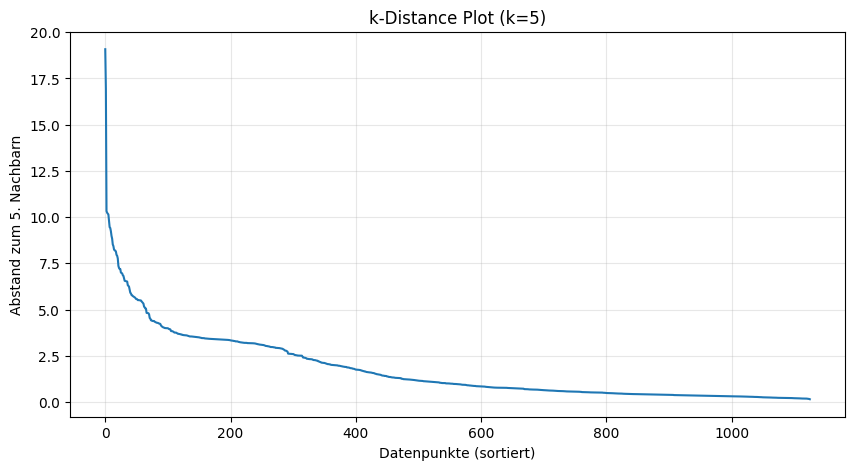

  90% der Punkte haben k-distance ≤ 0.298
  85% der Punkte haben k-distance ≤ 0.340
  80% der Punkte haben k-distance ≤ 0.385
  75% der Punkte haben k-distance ≤ 0.426
  70% der Punkte haben k-distance ≤ 0.509


In [485]:
# --- k-Distance Plot for eps estimation ---
min_samples_dbscan = 5

# Compute distance to k-th nearest neighbor for each point
neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors.fit(feature_matrix_contacts)
distances, _ = neighbors.kneighbors(feature_matrix_contacts)

# Sort distances to k-th neighbor (last column)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel('Datenpunkte (sortiert)')
plt.ylabel(f'Abstand zum {min_samples_dbscan}. Nachbarn')
plt.title(f'k-Distance Plot (k={min_samples_dbscan})')
plt.grid(True, alpha=0.3)
plt.show()

# Show quantiles to help determine eps
for q in [0.90, 0.85, 0.80, 0.75, 0.70]:
    val = np.quantile(k_distances, 1 - q)
    print(f'  {q:.0%} der Punkte haben k-distance \u2264 {val:.3f}')

### 3.2 DBSCAN ausf\u00fchren

Setze `eps_dbscan` basierend auf dem k-Distance Plot oben (dort wo der Knick ist).

In [486]:
# --- DBSCAN Clustering ---
# Adjust eps and min_samples here:
eps_dbscan = 3.7
min_samples_dbscan = 5

dbscan_model = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
dbscan_cluster_labels = dbscan_model.fit_predict(feature_matrix_contacts)

# Summarize results
n_clusters_dbscan = len(set(dbscan_cluster_labels)) - (1 if -1 in dbscan_cluster_labels else 0)
n_noise_dbscan = (dbscan_cluster_labels == -1).sum()
noise_ratio_dbscan = n_noise_dbscan / len(dbscan_cluster_labels)

print(f'DBSCAN (eps={eps_dbscan}, min_samples={min_samples_dbscan})')
print(f'  Gefundene Cluster: {n_clusters_dbscan}')
print(f'  Noise-Punkte:      {n_noise_dbscan} ({noise_ratio_dbscan:.1%})')

# Compute metrics (only possible with at least 2 clusters and not all noise)
if n_clusters_dbscan >= 2:
    non_noise_mask_dbscan = dbscan_cluster_labels != -1
    dbscan_silhouette = silhouette_score(
        feature_matrix_contacts[non_noise_mask_dbscan], dbscan_cluster_labels[non_noise_mask_dbscan]
    )
    dbscan_davies_bouldin = davies_bouldin_score(
        feature_matrix_contacts[non_noise_mask_dbscan], dbscan_cluster_labels[non_noise_mask_dbscan]
    )
    print(f'  Silhouette Score:     {dbscan_silhouette:.4f} (ohne Noise)')
    print(f'  Davies-Bouldin Index: {dbscan_davies_bouldin:.4f} (ohne Noise)')
else:
    dbscan_silhouette = np.nan
    dbscan_davies_bouldin = np.nan
    print('  Nicht genug Cluster f\u00fcr Metriken.')

print(f'\nCluster-Gr\u00f6\u00dfen (Label -1 = Noise):')
print(pd.Series(dbscan_cluster_labels).value_counts().sort_index().to_string())

DBSCAN (eps=3.7, min_samples=5)
  Gefundene Cluster: 13
  Noise-Punkte:      79 (7.0%)
  Silhouette Score:     0.2724 (ohne Noise)
  Davies-Bouldin Index: 1.1376 (ohne Noise)

Cluster-Größen (Label -1 = Noise):
-1      79
 0     704
 1      55
 2      42
 3      49
 4      32
 5      20
 6      18
 7      63
 8      14
 9      17
 10     14
 11      9
 12     10


## 4. HDBSCAN

HDBSCAN automatically determines the number of clusters based on density.
Points that don't belong to any dense region are labeled as **noise** (label = -1).

In [487]:
# default min_cluster_size = 10, min_samples = 5
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=2)
hdbscan_cluster_labels = hdbscan_model.fit_predict(feature_matrix_contacts)

n_clusters_hdbscan = len(set(hdbscan_cluster_labels)) - (1 if -1 in hdbscan_cluster_labels else 0)
n_noise_points = (hdbscan_cluster_labels == -1).sum()
noise_ratio_hdbscan = n_noise_points / len(hdbscan_cluster_labels)

print(f'HDBSCAN')
print(f'  Clusters found: {n_clusters_hdbscan}')
print(f'  Noise points:   {n_noise_points} ({noise_ratio_hdbscan:.1%})')

# Metrics only possible with at least 2 clusters (excluding noise)
if n_clusters_hdbscan >= 2:
    non_noise_mask = hdbscan_cluster_labels != -1
    hdbscan_silhouette = silhouette_score(
        feature_matrix_contacts[non_noise_mask], hdbscan_cluster_labels[non_noise_mask]
    )
    hdbscan_davies_bouldin = davies_bouldin_score(
        feature_matrix_contacts[non_noise_mask], hdbscan_cluster_labels[non_noise_mask]
    )
    print(f'  Silhouette Score:     {hdbscan_silhouette:.4f} (noise excluded)')
    print(f'  Davies-Bouldin Index: {hdbscan_davies_bouldin:.4f} (noise excluded)')
else:
    hdbscan_silhouette = np.nan
    hdbscan_davies_bouldin = np.nan
    print('  Not enough clusters for evaluation metrics.')

print(f'\nCluster sizes (label -1 = noise):')
print(pd.Series(hdbscan_cluster_labels).value_counts().sort_index().to_string())

HDBSCAN
  Clusters found: 14
  Noise points:   169 (15.0%)
  Silhouette Score:     0.2853 (noise excluded)
  Davies-Bouldin Index: 1.1619 (noise excluded)

Cluster sizes (label -1 = noise):
-1     169
 0      51
 1      50
 2      50
 3      63
 4      56
 5      73
 6     112
 7     115
 8      52
 9      62
 10     69
 11     67
 12     84
 13     53


## 5. Comparison of Clustering Methods

### 5.1 Metrics Table

| Metric | Meaning | Better |
|--------|---------|--------|
| Silhouette Score | Cluster cohesion vs. separation (-1 to 1) | Higher |
| Davies-Bouldin Index | Average similarity between clusters (\u2265 0) | Lower |

In [488]:
comparison_rows = []

# K-Means
comparison_rows.append({
    'Method': f'K-Means (k={optimal_k_kmeans})',
    'Clusters': optimal_k_kmeans,
    'Silhouette': round(kmeans_silhouette, 4),
    'Davies-Bouldin': round(kmeans_davies_bouldin, 4),
    'Noise Ratio': '0.0%'
})

# Hierarchical (Ward)
comparison_rows.append({
    'Method': 'Hierarchical (ward)',
    'Clusters': optimal_k_hierarchical,
    'Silhouette': round(hierarchical_sil, 4),
    'Davies-Bouldin': round(hierarchical_dbi, 4),
    'Noise Ratio': '0.0%'
})

# DBSCAN
comparison_rows.append({
    'Method': f'DBSCAN (eps={eps_dbscan})',
    'Clusters': n_clusters_dbscan,
    'Silhouette': round(dbscan_silhouette, 4) if not np.isnan(dbscan_silhouette) else 'N/A',
    'Davies-Bouldin': round(dbscan_davies_bouldin, 4) if not np.isnan(dbscan_davies_bouldin) else 'N/A',
    'Noise Ratio': f'{noise_ratio_dbscan:.1%}'
})

# HDBSCAN
comparison_rows.append({
    'Method': 'HDBSCAN',
    'Clusters': n_clusters_hdbscan,
    'Silhouette': round(hdbscan_silhouette, 4) if not np.isnan(hdbscan_silhouette) else 'N/A',
    'Davies-Bouldin': round(hdbscan_davies_bouldin, 4) if not np.isnan(hdbscan_davies_bouldin) else 'N/A',
    'Noise Ratio': f'{noise_ratio_hdbscan:.1%}'
})

df_comparison = pd.DataFrame(comparison_rows).set_index('Method')
df_comparison

,Clusters,Silhouette,Davies-Bouldin,Noise Ratio
Method,,,,
K-Means (k=12),12,0.2096,1.4190,0.0%
Hierarchical (ward),14,0.2352,1.2818,0.0%
DBSCAN (eps=3.7),13,0.2724,1.1376,7.0%
HDBSCAN,14,0.2853,1.1619,15.0%


### 5.2 PCA Visualization

All clustering results projected onto the first two principal components for visual comparison.

PCA explained variance: PC1=13.3%, PC2=10.2%, total=23.5%


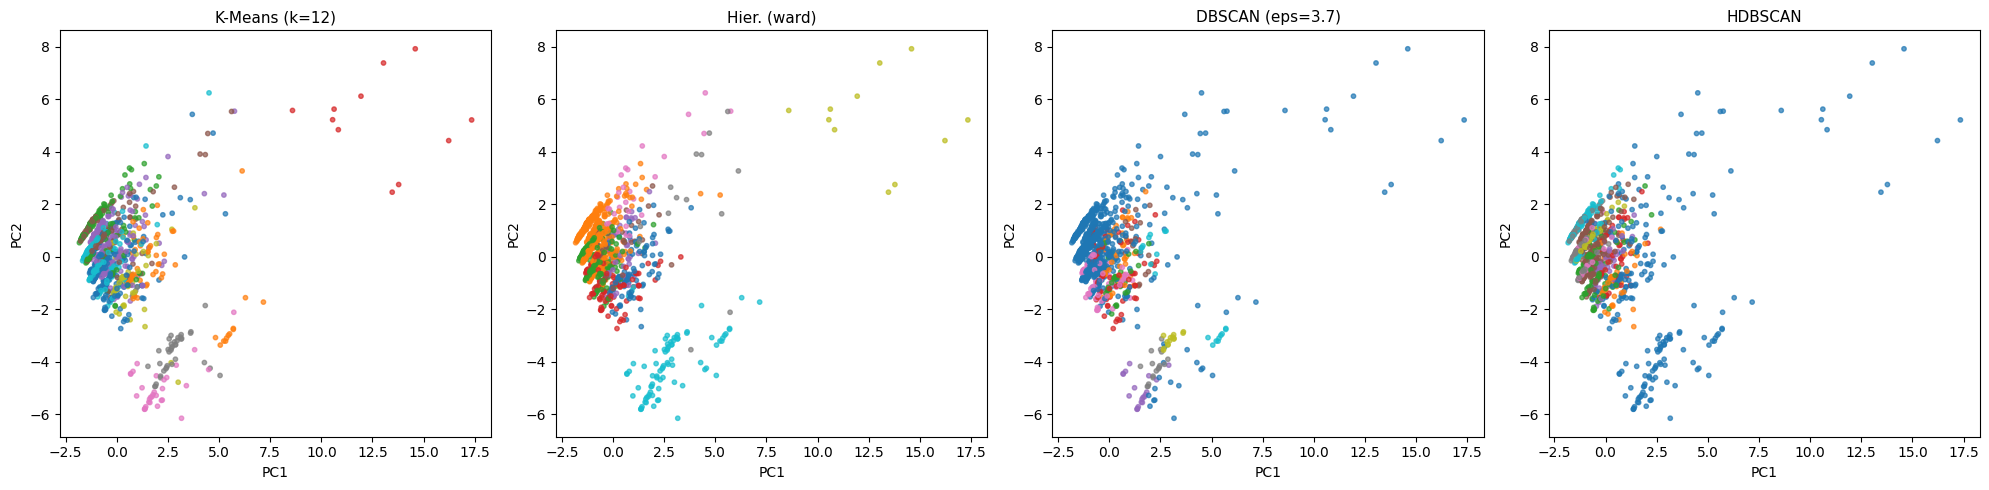

In [489]:
# Reduce to 2D for plotting
pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(feature_matrix_contacts)

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}, total={sum(pca.explained_variance_ratio_[:2]):.1%}')

# Collect all clustering results for plotting
all_cluster_label_sets = {
    f'K-Means (k={optimal_k_kmeans})': kmeans_cluster_labels,
}
all_cluster_label_sets['Hier. (ward)'] = hierarchical_cluster_labels
all_cluster_label_sets[f'DBSCAN (eps={eps_dbscan})'] = dbscan_cluster_labels
all_cluster_label_sets['HDBSCAN'] = hdbscan_cluster_labels

# Plot all methods in a grid
n_methods = len(all_cluster_label_sets)
n_cols = 4
n_rows = (n_methods + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, (method_name, labels) in enumerate(all_cluster_label_sets.items()):
    scatter = axes[i].scatter(
        pca_coordinates[:, 0], pca_coordinates[:, 1],
        c=labels, cmap='tab10', s=10, alpha=0.7
    )
    axes[i].set_title(method_name, fontsize=11)
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')

# Hide unused subplots
for j in range(n_methods, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Excel-Export: Cluster-Zuordnung pro Methode

F\u00fcr jede Clustering-Methode wird eine Excel-Datei im Ordner `Results/Contacts/` erstellt.  
- Jeder Ansprechpartner ist farblich nach Cluster markiert (gleiche Farben wie in der PCA-Visualisierung, `tab10` colormap).  
- Pro Cluster wird der **Silhouette Score** angezeigt.  
- Noise-Punkte (DBSCAN/HDBSCAN, Label = -1) werden grau dargestellt.

In [490]:
import os
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import silhouette_samples
import matplotlib.colors as mcolors
from scipy.spatial.distance import cdist

# Load contact name mapping
df_contact_name_mapping = pd.read_excel('data/contact_id_mapping.xlsx', index_col=0)
contact_id_to_name = df_contact_name_mapping.apply(
    lambda row: f"{row['first_name']} {row['last_name']} ({row['company_name']})", axis=1
).to_dict()

# Create Results/Contacts folder
os.makedirs('Results/Contacts', exist_ok=True)

# Convert tab10 colormap to hex (same as used in PCA scatter plots)
tab10_cmap = plt.cm.tab10
def label_to_hex(label):
    """Convert cluster label to hex color matching tab10 colormap."""
    if label == -1:
        return 'C0C0C0'  # grey for noise
    rgba = tab10_cmap(label % 10)
    return mcolors.rgb2hex(rgba[:3]).replace('#', '')

def label_to_font_color(label):
    """Return black or white font depending on background brightness."""
    if label == -1:
        return '000000'
    rgba = tab10_cmap(label % 10)
    brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'FFFFFF' if brightness < 0.5 else '000000'

def compute_per_cluster_silhouette(X, labels):
    """Compute silhouette score for each cluster individually."""
    sample_sil = silhouette_samples(X, labels)
    unique_labels = sorted(set(labels))
    result = {}
    for lbl in unique_labels:
        mask = labels == lbl
        result[lbl] = float(np.mean(sample_sil[mask]))
    return result

def export_contact_cluster_excel(filename, method_name, labels, feature_data, index_ids, df_with_columns):
    """
    Create a well-formatted Excel file showing cluster membership for contacts.
    One sheet per cluster + a summary sheet + a Median sheet.
    """
    labels = np.array(labels)
    feature_columns = df_with_columns.columns.tolist()
    
    # Compute per-cluster silhouette (exclude noise for metrics if present)
    unique_labels = sorted(set(labels))
    has_noise = -1 in unique_labels
    
    non_noise_labels = [l for l in unique_labels if l != -1]
    if len(non_noise_labels) >= 2:
        if has_noise:
            mask = labels != -1
            per_cluster_sil = compute_per_cluster_silhouette(feature_data[mask], labels[mask])
        else:
            per_cluster_sil = compute_per_cluster_silhouette(feature_data, labels)
    else:
        per_cluster_sil = {l: np.nan for l in unique_labels}

    wb = Workbook()
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin')
    )
    
    # --- Summary sheet ---
    ws_summary = wb.active
    ws_summary.title = '\u00dcbersicht'
    
    headers = ['Cluster', 'Anzahl Ansprechpartner', 'Silhouette Score']
    for col, h in enumerate(headers, 1):
        cell = ws_summary.cell(row=1, column=col, value=h)
        cell.font = Font(bold=True, size=12)
        cell.border = thin_border
        cell.alignment = Alignment(horizontal='center')
    
    for row_idx, lbl in enumerate(unique_labels, 2):
        cluster_name = f'Noise (kein Cluster)' if lbl == -1 else f'Cluster {lbl}'
        count = int(np.sum(labels == lbl))
        sil_val = per_cluster_sil.get(lbl, np.nan)
        
        bg_hex = label_to_hex(lbl)
        fg_hex = label_to_font_color(lbl)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font = Font(color=fg_hex, size=11)
        
        for col, val in enumerate([cluster_name, count, round(sil_val, 4) if not np.isnan(sil_val) else 'N/A'], 1):
            cell = ws_summary.cell(row=row_idx, column=col, value=val)
            cell.fill = fill
            cell.font = font
            cell.border = thin_border
            cell.alignment = Alignment(horizontal='center')
    
    # Auto-width for summary
    for col in range(1, 4):
        ws_summary.column_dimensions[get_column_letter(col)].width = 26
    
    # --- One sheet per cluster ---
    for lbl in unique_labels:
        sheet_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ws = wb.create_sheet(title=sheet_name)
        
        bg_hex = label_to_hex(lbl)
        fg_hex = label_to_font_color(lbl)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font_colored = Font(color=fg_hex, size=11)
        
        sil_val = per_cluster_sil.get(lbl, np.nan)
        
        # Header row
        header_texts = ['#', 'Contact ID', 'Ansprechpartner', 'Cluster', 'Silhouette Score (Cluster)']
        for col, h in enumerate(header_texts, 1):
            cell = ws.cell(row=1, column=col, value=h)
            cell.font = Font(bold=True, size=12)
            cell.border = thin_border
            cell.alignment = Alignment(horizontal='center')
        
        # Data rows
        cluster_mask = labels == lbl
        cluster_ids = np.array(index_ids)[cluster_mask]
        
        for row_i, cid in enumerate(cluster_ids, 2):
            contact_display_name = contact_id_to_name.get(cid, f'ID {cid}')
            cluster_display = 'Noise' if lbl == -1 else lbl
            sil_display = round(sil_val, 4) if not np.isnan(sil_val) else 'N/A'
            
            for col, val in enumerate([row_i - 1, cid, contact_display_name, cluster_display, sil_display], 1):
                cell = ws.cell(row=row_i, column=col, value=val)
                cell.fill = fill
                cell.font = font_colored
                cell.border = thin_border
                if col != 3:  # center everything except contact name
                    cell.alignment = Alignment(horizontal='center')
        
        # Column widths
        ws.column_dimensions['A'].width = 6
        ws.column_dimensions['B'].width = 14
        ws.column_dimensions['C'].width = 50
        ws.column_dimensions['D'].width = 12
        ws.column_dimensions['E'].width = 26
    
    # --- Median sheet: Median of all features per cluster + Medoid ID ---
    ws_median = wb.create_sheet(title='Cluster-Mediane')
    
    # Header: Cluster, Medoid ID, Medoid Name, then all feature columns
    median_headers = ['Cluster', 'Medoid ID', 'Medoid Ansprechpartner'] + feature_columns
    for col, h in enumerate(median_headers, 1):
        cell = ws_median.cell(row=1, column=col, value=h)
        cell.font = Font(bold=True, size=11)
        cell.border = thin_border
        cell.alignment = Alignment(horizontal='center')
    
    # One row per cluster: median values + closest real contact to the median
    for row_idx, lbl in enumerate(unique_labels, 2):
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_mask = labels == lbl
        cluster_data = feature_data[cluster_mask]
        cluster_ids = np.array(index_ids)[cluster_mask]
        median_values = np.median(cluster_data, axis=0)
        
        # Medoid: contact closest to the median
        distances = cdist([median_values], cluster_data, metric='euclidean')[0]
        closest_idx = np.argmin(distances)
        medoid_id = cluster_ids[closest_idx]
        medoid_name = contact_id_to_name.get(medoid_id, f'ID {medoid_id}')
        
        bg_hex = label_to_hex(lbl)
        fg_hex = label_to_font_color(lbl)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font_colored = Font(color=fg_hex, size=11)
        
        row_vals = [cluster_name, medoid_id, medoid_name] + [round(float(v), 4) for v in median_values]
        for col_idx, val in enumerate(row_vals, 1):
            cell = ws_median.cell(row=row_idx, column=col_idx, value=val)
            cell.fill = fill
            cell.font = font_colored
            cell.border = thin_border
            if col_idx != 3:  # contact name left-aligned
                cell.alignment = Alignment(horizontal='center')
    
    # Column widths for Median sheet
    ws_median.column_dimensions['A'].width = 16
    ws_median.column_dimensions['B'].width = 12
    ws_median.column_dimensions['C'].width = 50
    for col_idx in range(4, len(median_headers) + 1):
        ws_median.column_dimensions[get_column_letter(col_idx)].width = max(14, len(median_headers[col_idx - 1]) + 2)
    
    filepath = os.path.join('Results', 'Contacts', filename)
    wb.save(filepath)
    print(f'  Saved: {filepath} ({len(unique_labels)} cluster sheets + Median sheet)')
    return per_cluster_sil

# --- Export all clustering results ---

index_ids = df_contacts_scaled.index.tolist()

print('=== Excel-Export ===\n')

# 1) K-Means
print(f'K-Means (k={optimal_k_kmeans}):')
kmeans_per_cluster_sil = export_contact_cluster_excel(
    'KMeans_Contacts_Cluster.xlsx', 'K-Means', kmeans_cluster_labels, feature_matrix_contacts, index_ids, df_contacts_scaled
)

# 2) Hierarchical (Ward)
print(f'\nHierarchical (ward):')
export_contact_cluster_excel(
    'Hierarchical_ward_Contacts_Cluster.xlsx', 'Hier. (ward)', hierarchical_cluster_labels, feature_matrix_contacts, index_ids, df_contacts_scaled
)

# 3) DBSCAN
print(f'\nDBSCAN (eps={eps_dbscan}):')
dbscan_per_cluster_sil = export_contact_cluster_excel(
    'DBSCAN_Contacts_Cluster.xlsx', 'DBSCAN', dbscan_cluster_labels, feature_matrix_contacts, index_ids, df_contacts_scaled
)

# 4) HDBSCAN
print(f'\nHDBSCAN:')
hdbscan_per_cluster_sil = export_contact_cluster_excel(
    'HDBSCAN_Contacts_Cluster.xlsx', 'HDBSCAN', hdbscan_cluster_labels, feature_matrix_contacts, index_ids, df_contacts_scaled
)

print('\n=== All Excel files saved to Results/Contacts/ ===')

=== Excel-Export ===

K-Means (k=12):
  Saved: Results\Contacts\KMeans_Contacts_Cluster.xlsx (12 cluster sheets + Median sheet)

Hierarchical (ward):
  Saved: Results\Contacts\Hierarchical_ward_Contacts_Cluster.xlsx (14 cluster sheets + Median sheet)

DBSCAN (eps=3.7):
  Saved: Results\Contacts\DBSCAN_Contacts_Cluster.xlsx (14 cluster sheets + Median sheet)

HDBSCAN:
  Saved: Results\Contacts\HDBSCAN_Contacts_Cluster.xlsx (15 cluster sheets + Median sheet)

=== All Excel files saved to Results/Contacts/ ===


In [491]:
# --- Silhouette Score per cluster - summary in notebook ---
print('=== Silhouette Score pro Cluster ===\n')

all_results = {}

# K-Means
all_results[f'K-Means (k={optimal_k_kmeans})'] = kmeans_per_cluster_sil

# Hierarchical (Ward)
unique = sorted(set(hierarchical_cluster_labels))
if len(unique) >= 2:
    sil = compute_per_cluster_silhouette(feature_matrix_contacts, hierarchical_cluster_labels)
else:
    sil = {l: np.nan for l in unique}
all_results['Hier. (ward)'] = sil

# DBSCAN
all_results[f'DBSCAN (eps={eps_dbscan})'] = dbscan_per_cluster_sil

# HDBSCAN
all_results['HDBSCAN'] = hdbscan_per_cluster_sil

# Build a summary DataFrame
rows = []
for method_name, sil_dict in all_results.items():
    for lbl, score in sorted(sil_dict.items()):
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        rows.append({'Methode': method_name, 'Cluster': cluster_name, 'Silhouette Score': round(score, 4)})

df_sil_summary = pd.DataFrame(rows)
print(df_sil_summary.to_string(index=False))

=== Silhouette Score pro Cluster ===

         Methode    Cluster  Silhouette Score
  K-Means (k=12)  Cluster 0            0.1202
  K-Means (k=12)  Cluster 1            0.2675
  K-Means (k=12)  Cluster 2            0.1075
  K-Means (k=12)  Cluster 3            0.2486
  K-Means (k=12)  Cluster 4            0.5531
  K-Means (k=12)  Cluster 5            0.1367
  K-Means (k=12)  Cluster 6            0.2327
  K-Means (k=12)  Cluster 7            0.3660
  K-Means (k=12)  Cluster 8            0.3087
  K-Means (k=12)  Cluster 9            0.2535
  K-Means (k=12) Cluster 10            0.3929
  K-Means (k=12) Cluster 11            0.2251
    Hier. (ward)  Cluster 1            0.2739
    Hier. (ward)  Cluster 2            0.2159
    Hier. (ward)  Cluster 3            0.2074
    Hier. (ward)  Cluster 4            0.2501
    Hier. (ward)  Cluster 5            0.3241
    Hier. (ward)  Cluster 6            0.3235
    Hier. (ward)  Cluster 7            0.2713
    Hier. (ward)  Cluster 8            0.2

In [492]:
# --- Cluster medians + Medoid ID in notebook ---
from scipy.spatial.distance import cdist

print('=== Cluster-Mediane (mit Medoid = n\u00e4chster realer Ansprechpartner zum Median) ===\n')

feature_columns = df_contacts_scaled.columns.tolist()

all_median_results = {}

# K-Means
all_median_results[f'K-Means (k={optimal_k_kmeans})'] = kmeans_cluster_labels

# Hierarchical (Ward)
all_median_results['Hier. (ward)'] = hierarchical_cluster_labels

# DBSCAN
all_median_results[f'DBSCAN (eps={eps_dbscan})'] = dbscan_cluster_labels

# HDBSCAN
all_median_results['HDBSCAN'] = hdbscan_cluster_labels

index_ids = df_contacts_scaled.index.tolist()

for method_name, labels in all_median_results.items():
    labels = np.array(labels)
    unique_labels = sorted(set(labels))
    
    rows = []
    for lbl in unique_labels:
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_mask = labels == lbl
        cluster_data = feature_matrix_contacts[cluster_mask]
        cluster_ids = np.array(index_ids)[cluster_mask]
        median_vals = np.median(cluster_data, axis=0)
        
        # Medoid: contact closest to the median
        distances = cdist([median_vals], cluster_data, metric='euclidean')[0]
        closest_idx = np.argmin(distances)
        medoid_id = cluster_ids[closest_idx]
        medoid_name = contact_id_to_name.get(medoid_id, f'ID {medoid_id}')
        
        row = {'Cluster': cluster_name, 'Medoid ID': medoid_id, 'Medoid Ansprechpartner': medoid_name}
        for col_name, val in zip(feature_columns, median_vals):
            row[col_name] = round(val, 4)
        rows.append(row)
    
    df_medians = pd.DataFrame(rows)
    print(f'--- {method_name} ---')
    print(df_medians.to_string(index=False))
    print()

=== Cluster-Mediane (mit Medoid = nächster realer Ansprechpartner zum Median) ===

--- K-Means (k=12) ---
   Cluster  Medoid ID                                               Medoid Ansprechpartner  Recency  Frequency  Regale  Lager Zubehör  Sonstige Produkte  Monetary Value  Werkstätte_gesamt  Garderoben_gesamt  industry_group_ZG 1+2  industry_group_ZG 3+4  industry_group_ZG 5+6  industry_group_ZG 7  industry_group_ZG 8  industry_group_ZG 9  bundesland_Ost  bundesland_Süd  bundesland_West  company_size_Groß  company_size_Klein  company_size_Mittel  department_Einkauf & Beschaffung  department_Führung & Leitung  department_Technik & Produktion  department_Verwaltung & Vertrieb  type_detail_Gewerbl. Nutzer  type_detail_Multiplikator  type_detail_Wiederverkäufer
 Cluster 0        651   Josef Neuherz (Wien Work integrative Betriebe und AusbildungsgmbH)  -0.1821    -0.0399 -0.3175        -0.1327            -0.3193         -0.3657            -0.2004            -0.3452                -0.5177 

## 7. Medoid-\u00dcbersicht mit unskalierten Werten

Die skalierten Werte sind schwer zu interpretieren. Hier werden die Medoids (der reale Ansprechpartner, der den Cluster am besten repr\u00e4sentiert) mit ihren **originalen, unskalierten Werten** aus `df_contacts_final_before_scaler.csv` angezeigt.

In [493]:
# --- Medoids with unscaled values ---
df_contacts_unscaled = pd.read_csv('data/df_contacts_final_before_scaler.csv', index_col='contact_id')
print(f'Unskalierte Daten geladen: {df_contacts_unscaled.shape}')

thin_border = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'), bottom=Side(style='thin')
)

# Collect all clustering results
all_clustering_labels = {
    f'K-Means (k={optimal_k_kmeans})': kmeans_cluster_labels,
}
all_clustering_labels['Hier. (ward)'] = hierarchical_cluster_labels
all_clustering_labels[f'DBSCAN (eps={eps_dbscan})'] = dbscan_cluster_labels
all_clustering_labels['HDBSCAN'] = hdbscan_cluster_labels

index_ids = df_contacts_scaled.index.tolist()

# Per method: find medoids and display unscaled rows
wb_medoids = Workbook()
wb_medoids.remove(wb_medoids.active)

for method_name, labels in all_clustering_labels.items():
    labels = np.array(labels)
    unique_labels = sorted(set(labels))
    
    medoid_rows = []
    for lbl in unique_labels:
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_mask = labels == lbl
        cluster_data = feature_matrix_contacts[cluster_mask]
        cluster_ids = np.array(index_ids)[cluster_mask]
        
        # Medoid: closest contact to median
        median_vals = np.median(cluster_data, axis=0)
        distances = cdist([median_vals], cluster_data, metric='euclidean')[0]
        medoid_id = cluster_ids[np.argmin(distances)]
        
        # Get unscaled row
        if medoid_id in df_contacts_unscaled.index:
            row = df_contacts_unscaled.loc[medoid_id].copy()
            row['Cluster'] = cluster_name
            row['Ansprechpartner'] = contact_id_to_name.get(medoid_id, f'ID {medoid_id}')
            row.name = medoid_id
            medoid_rows.append(row)
    
    df_medoids = pd.DataFrame(medoid_rows)
    # Move Cluster and Ansprechpartner to front
    cols = ['Cluster', 'Ansprechpartner'] + [c for c in df_medoids.columns if c not in ['Cluster', 'Ansprechpartner']]
    df_medoids = df_medoids[cols]
    
    # Display in notebook
    print(f'\n--- {method_name} ---')
    print(df_medoids.to_string())
    
    # Write to Excel
    sheet_name = method_name[:31]
    ws = wb_medoids.create_sheet(title=sheet_name)
    
    # Header
    header = ['Contact ID'] + cols
    for col_idx, h in enumerate(header, 1):
        cell = ws.cell(row=1, column=col_idx, value=h)
        cell.font = Font(bold=True, size=11)
        cell.border = thin_border
        cell.alignment = Alignment(horizontal='center')
    
    # Data rows
    for row_idx, (cid, row_data) in enumerate(df_medoids.iterrows(), 2):
        lbl_str = row_data['Cluster']
        if lbl_str == 'Noise':
            lbl_num = -1
        else:
            lbl_num = int(lbl_str.replace('Cluster ', ''))
        
        bg_hex = label_to_hex(lbl_num)
        fg_hex = label_to_font_color(lbl_num)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font_colored = Font(color=fg_hex, size=11)
        
        vals = [cid] + [row_data[c] for c in cols]
        for col_idx, val in enumerate(vals, 1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.fill = fill
            cell.font = font_colored
            cell.border = thin_border
            if col_idx != 3:  # Ansprechpartner left-aligned
                cell.alignment = Alignment(horizontal='center')
    
    # Column widths
    ws.column_dimensions['A'].width = 14
    ws.column_dimensions['B'].width = 14
    ws.column_dimensions['C'].width = 50
    for col_idx in range(4, len(header) + 1):
        ws.column_dimensions[get_column_letter(col_idx)].width = max(12, len(header[col_idx - 1]) + 2)

wb_medoids.save('Results/Contacts/Medoids_unskaliert.xlsx')
print(f'\nSaved: Results/Contacts/Medoids_unskaliert.xlsx')

Unskalierte Daten geladen: (1126, 27)

--- K-Means (k=12) ---
         Cluster                                                       Ansprechpartner  Recency  Frequency    Regale  Lager Zubehör  Sonstige Produkte  Monetary Value  Werkstätte_gesamt  Garderoben_gesamt  industry_group_ZG 1+2  industry_group_ZG 3+4  industry_group_ZG 5+6  industry_group_ZG 7  industry_group_ZG 8  industry_group_ZG 9  bundesland_Ost  bundesland_Süd  bundesland_West  company_size_Groß  company_size_Klein  company_size_Mittel  department_Einkauf & Beschaffung  department_Führung & Leitung  department_Technik & Produktion  department_Verwaltung & Vertrieb  type_detail_Gewerbl. Nutzer  type_detail_Multiplikator  type_detail_Wiederverkäufer
651    Cluster 0    Josef Neuherz (Wien Work integrative Betriebe und AusbildungsgmbH)    947.0        1.0      0.00            0.0                0.0          538.00               0.00              538.0                    0.0                    0.0                    0.0   

In [494]:
# --- Cluster averages with unscaled values ---
wb_avg = Workbook()
wb_avg.remove(wb_avg.active)

for method_name, labels in all_clustering_labels.items():
    labels = np.array(labels)
    unique_labels = sorted(set(labels))
    
    avg_rows = []
    for lbl in unique_labels:
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_mask = labels == lbl
        cluster_ids = np.array(index_ids)[cluster_mask]
        
        # Unscaled data for this cluster
        cluster_unscaled = df_contacts_unscaled.loc[df_contacts_unscaled.index.isin(cluster_ids)]
        if len(cluster_unscaled) == 0:
            continue
        
        avg = cluster_unscaled.mean(numeric_only=True)
        avg['Cluster'] = cluster_name
        avg['Anzahl Ansprechpartner'] = len(cluster_unscaled)
        avg_rows.append(avg)
    
    df_avg = pd.DataFrame(avg_rows)
    # Move Cluster and count to front
    cols = ['Cluster', 'Anzahl Ansprechpartner'] + [c for c in df_avg.columns if c not in ['Cluster', 'Anzahl Ansprechpartner']]
    df_avg = df_avg[cols]
    
    # Display in notebook
    print(f'\n--- {method_name} (Durchschnitt) ---')
    print(df_avg.to_string(index=False))
    
    # Write to Excel
    sheet_name = method_name[:31]
    ws = wb_avg.create_sheet(title=sheet_name)
    
    # Header
    header = list(cols)
    for col_idx, h in enumerate(header, 1):
        cell = ws.cell(row=1, column=col_idx, value=h)
        cell.font = Font(bold=True, size=11)
        cell.border = thin_border
        cell.alignment = Alignment(horizontal='center')
    
    # Data rows
    for row_idx, (_, row_data) in enumerate(df_avg.iterrows(), 2):
        lbl_str = row_data['Cluster']
        if lbl_str == 'Noise':
            lbl_num = -1
        else:
            lbl_num = int(lbl_str.replace('Cluster ', ''))
        
        bg_hex = label_to_hex(lbl_num)
        fg_hex = label_to_font_color(lbl_num)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font_colored = Font(color=fg_hex, size=11)
        
        for col_idx, c in enumerate(cols, 1):
            val = row_data[c]
            if isinstance(val, float):
                val = round(val, 2)
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.fill = fill
            cell.font = font_colored
            cell.border = thin_border
            if col_idx != 1:  # Cluster left-aligned
                cell.alignment = Alignment(horizontal='center')
    
    # Column widths
    ws.column_dimensions['A'].width = 14
    ws.column_dimensions['B'].width = 22
    for col_idx in range(3, len(header) + 1):
        ws.column_dimensions[get_column_letter(col_idx)].width = max(12, len(header[col_idx - 1]) + 2)

wb_avg.save('Results/Contacts/Cluster_Durchschnitte_unskaliert.xlsx')
print(f'\nSaved: Results/Contacts/Cluster_Durchschnitte_unskaliert.xlsx')


--- K-Means (k=12) (Durchschnitt) ---
   Cluster  Anzahl Ansprechpartner     Recency  Frequency       Regale  Lager Zubehör  Sonstige Produkte  Monetary Value  Werkstätte_gesamt  Garderoben_gesamt  industry_group_ZG 1+2  industry_group_ZG 3+4  industry_group_ZG 5+6  industry_group_ZG 7  industry_group_ZG 8  industry_group_ZG 9  bundesland_Ost  bundesland_Süd  bundesland_West  company_size_Groß  company_size_Klein  company_size_Mittel  department_Einkauf & Beschaffung  department_Führung & Leitung  department_Technik & Produktion  department_Verwaltung & Vertrieb  type_detail_Gewerbl. Nutzer  type_detail_Multiplikator  type_detail_Wiederverkäufer
 Cluster 0                     163  999.981595   0.920245  2588.907669     170.729939        1704.781902    12550.364908        2653.961288        5431.984110               0.000000               0.085890               0.085890             0.687117             0.000000             0.141104        1.000000        0.000000         0.000000      